# Analysis Notebook
This notebook implements Plan 08 in a code-first, reproducible way for non-data-scientist users.

Run order:
1. Run `python src/cleaning.py` first.
2. Open this notebook and use **Run All**.
3. Review outputs in `outputs/tables`, `outputs/figures`, and `outputs/analysis_report.html`.

## What Each Section Does
1. Configuration: defines file paths, station settings, and modeling controls.
2. Environment setup: imports libraries and prepares output folders.
3. Guardrails/helpers: validates schema and provides shared metrics.
4. Data loading: reads cleaned hourly data and enforces timestamp integrity.
5. Data quality: calculates coverage, missingness, and noon-readiness.
6. Similarity EDA: compares station pairs across core variables and seasons.
7. FWI modeling: computes daily moisture codes and FWI, then validates against ECCC.
8. Redundancy modeling: uses station-level PCA and pairwise distance overlap vs Stanhope.
9. Decision layer: estimates uncertainty and exports a plain-language report.

In [1]:
# =============================================================================
# CONFIGURATION CELL
# Purpose: centralize all run-time settings in one place.
# Junior note: change values here instead of editing later logic cells.
# =============================================================================

from pathlib import Path

# Base project paths (assumes notebook launched from project root).
PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
SCRUBBED_DIR = PROJECT_ROOT / "data" / "scrubbed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
LOGS_DIR = OUTPUTS_DIR / "logs"

# Core inputs used by this notebook.
HOURLY_INPUT = SCRUBBED_DIR / "02_hourly_weather_utc.csv"
REFERENCE_FWI_DIR = RAW_DIR / "ECCC_Stanhope_FWI"

# Business comparison targets.
REFERENCE_STATION = "Stanhope"
CANDIDATE_STATIONS = ["Cavendish", "Greenwich"]
FWI_DELTA_THRESHOLD = 2.0

# Reproducibility and model controls.
RANDOM_SEED = 42
START_DATE_UTC = None  # Optional filter, e.g. "2023-01-01"
END_DATE_UTC = None    # Optional filter, e.g. "2025-12-31"
PLOTTING_STYLE = "whitegrid"

**Expected Output (Cell 2)**
- No table output is expected.
- This cell should run silently with no errors.
- Key variables (paths, thresholds, station names) are now available for all downstream cells.

In [2]:
# =============================================================================
# ENVIRONMENT SETUP CELL
# Purpose: import libraries, set plotting style, and ensure output directories.
# =============================================================================

import math
from datetime import datetime, timedelta, timezone
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Make random operations deterministic for reproducible results.
np.random.seed(RANDOM_SEED)
sns.set_theme(style=PLOTTING_STYLE)

# Ensure all output folders exist before writing any artifacts.
for path in [OUTPUTS_DIR, FIGURES_DIR, TABLES_DIR, LOGS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Run All note: This notebook writes production artifacts to outputs/tables and outputs/figures.")
print(f"Project root: {PROJECT_ROOT}")
display(Markdown("### Business-Friendly Output Mode\nThis notebook now both saves artifact files and shows the most important summaries directly below each section."))

Run All note: This notebook writes production artifacts to outputs/tables and outputs/figures.
Project root: c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather


### Business-Friendly Output Mode
This notebook now both saves artifact files and shows the most important summaries directly below each section.

**Expected Output (Cell 3)**
- Prints project/run messages, including the detected project root.
- Creates output directories if they do not already exist.
- Displays a short markdown note confirming business-friendly output mode.

In [3]:
# =============================================================================
# GUARDRAIL AND METRIC HELPER CELL
# Purpose: define validation helpers and shared metric functions used later.
# =============================================================================

HALIFAX_TZ = ZoneInfo("America/Halifax")
UTC_TZ = ZoneInfo("UTC")

# Canonical variables expected from cleaned hourly data.
CANONICAL_VARS = [
    "air_temperature_c",
    "relative_humidity_pct",
    "wind_speed_kmh",
    "wind_direction_deg",
    "precipitation_mm",
]
CORE_VARS = ["air_temperature_c", "relative_humidity_pct", "wind_speed_kmh"]


def fail(msg: str) -> None:
    """Raise a hard-stop error with a readable message."""
    raise ValueError(msg)


def require_columns(df: pd.DataFrame, required: list[str], name: str) -> None:
    """Fail early if required columns are missing from an input dataframe."""
    missing = [c for c in required if c not in df.columns]
    if missing:
        fail(f"{name} missing required columns: {missing}")


def to_numeric_safe(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Convert selected columns to numeric and coerce non-numeric values to NaN."""
    out = df.copy()
    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def calc_rmse(a: pd.Series, b: pd.Series) -> float:
    """Root Mean Squared Error between aligned series."""
    if len(a) == 0:
        return float("nan")
    return float(np.sqrt(np.nanmean((a - b) ** 2)))


def calc_mae(a: pd.Series, b: pd.Series) -> float:
    """Mean Absolute Error between aligned series."""
    if len(a) == 0:
        return float("nan")
    return float(np.nanmean(np.abs(a - b)))


def calc_bias(a: pd.Series, b: pd.Series) -> float:
    """Signed mean error (positive means first series is higher on average)."""
    if len(a) == 0:
        return float("nan")
    return float(np.nanmean(a - b))


def calc_corr(a: pd.Series, b: pd.Series, method: str = "pearson") -> float:
    """Correlation helper with minimum length protection."""
    if len(a) < 3:
        return float("nan")
    return float(a.corr(b, method=method))


print("Guardrails initialized.")

Guardrails initialized.


**Expected Output (Cell 4)**
- Prints `Guardrails initialized.`
- No data tables are created yet.
- Helper functions and metric utilities are now defined and ready for use.

In [4]:
# =============================================================================
# LOAD CLEANED HOURLY DATA
# Purpose: read scrubbed data and enforce strict structural/time integrity.
# =============================================================================

# Hard-stop if the required cleaned file is not present.
if not HOURLY_INPUT.exists():
    fail(f"Missing cleaned input. Run cleaning first: {HOURLY_INPUT}")

# Load full hourly dataset produced by src/cleaning.py.
hourly = pd.read_csv(HOURLY_INPUT, low_memory=False)
required_cols = ["datetime_utc", "station_slug", "station_raw", "source", *CANONICAL_VARS]
require_columns(hourly, required_cols, "hourly")

# Coerce weather variables to numeric (bad values become NaN).
hourly = to_numeric_safe(hourly, CANONICAL_VARS)

# Parse and validate UTC timestamps.
hourly["datetime_utc"] = pd.to_datetime(hourly["datetime_utc"], utc=True, errors="coerce")
if hourly["datetime_utc"].isna().any():
    fail(f"Invalid UTC timestamps found: {int(hourly['datetime_utc'].isna().sum())}")

# Optional user-supplied date filters.
if START_DATE_UTC:
    hourly = hourly[hourly["datetime_utc"] >= pd.Timestamp(START_DATE_UTC, tz="UTC")]
if END_DATE_UTC:
    hourly = hourly[hourly["datetime_utc"] <= pd.Timestamp(END_DATE_UTC, tz="UTC")]

# Ensure one row per station per hour.
dupes = hourly.duplicated(subset=["station_slug", "datetime_utc"])
if bool(dupes.any()):
    fail(f"Duplicate station/timestamp rows found: {int(dupes.sum())}")

# Keep rows sorted for deterministic downstream behavior.
hourly = hourly.sort_values(["station_slug", "datetime_utc"]).reset_index(drop=True)
print(f"Loaded rows: {len(hourly):,}")
print(f"Stations: {hourly['station_slug'].nunique()}")
print(f"UTC range: {hourly['datetime_utc'].min()} -> {hourly['datetime_utc'].max()}")

Loaded rows: 166,087
Stations: 6
UTC range: 2022-01-01 04:00:00+00:00 -> 2026-01-01 03:00:00+00:00


**Expected Output (Cell 5)**
- Prints row count, number of stations, and UTC date range.
- If data issues exist (missing file, bad timestamps, duplicates), the cell stops with a clear error.
- On success, the clean `hourly` dataframe is ready for quality and modeling steps.

In [5]:
# =============================================================================
# DATA QUALITY ANALYSIS
# Purpose: quantify coverage, missingness, and noon-readiness for FWI workflows.
# =============================================================================

# ---- Overall coverage by station and variable ----
coverage_rows = []
for (station_slug, station_raw), g in hourly.groupby(["station_slug", "station_raw"], dropna=False):
    total_hours = len(g)
    for var in CANONICAL_VARS:
        missing_hours = int(g[var].isna().sum())
        coverage_rows.append(
            {
                "station_slug": station_slug,
                "station_raw": station_raw,
                "variable": var,
                "total_hours": total_hours,
                "missing_hours": missing_hours,
                "missing_pct": (missing_hours / total_hours * 100.0) if total_hours else np.nan,
            }
        )
coverage_overall = pd.DataFrame(coverage_rows)
coverage_overall.to_csv(TABLES_DIR / "03_explore_coverage_overall.csv", index=False)

# ---- Monthly coverage trends (helps detect season-specific outages) ----
work = hourly.copy()
work["year_month"] = work["datetime_utc"].dt.tz_localize(None).dt.to_period("M").astype(str)
monthly_rows = []
for (station_slug, station_raw, ym), g in work.groupby(["station_slug", "station_raw", "year_month"], dropna=False):
    total_hours = len(g)
    for var in CANONICAL_VARS:
        missing_hours = int(g[var].isna().sum())
        monthly_rows.append(
            {
                "station_slug": station_slug,
                "station_raw": station_raw,
                "year_month": ym,
                "variable": var,
                "total_hours": total_hours,
                "missing_hours": missing_hours,
                "missing_pct": (missing_hours / total_hours * 100.0) if total_hours else np.nan,
            }
        )
coverage_monthly = pd.DataFrame(monthly_rows)
coverage_monthly.to_csv(TABLES_DIR / "03_explore_coverage_monthly.csv", index=False)

# ---- Noon readiness for fire-weather operations ----
# FWI workflows require reliable noon meteorology and a complete prior 24h precip window.
noon_rows = []
for station_slug, g in hourly.groupby("station_slug", dropna=False):
    s = g.copy()
    s["datetime_local"] = s["datetime_utc"].dt.tz_convert(HALIFAX_TZ)
    s["local_date"] = s["datetime_local"].dt.date
    s["local_hour"] = s["datetime_local"].dt.hour
    noon = s[s["local_hour"] == 12].copy()
    days_with_noon = int(noon["local_date"].nunique())
    core_ready = noon[CORE_VARS].notna().all(axis=1)
    days_core_ready = int(noon.loc[core_ready, "local_date"].nunique())

    precip = s.set_index("datetime_utc")["precipitation_mm"]
    precip_ready = 0
    for d in sorted(noon["local_date"].dropna().unique().tolist()):
        # Rain window: previous local day 13:00 through current local day 12:00 (24 hourly values).
        start_local = datetime.combine(d - timedelta(days=1), datetime.min.time().replace(hour=13), tzinfo=HALIFAX_TZ)
        window_local = pd.date_range(start=start_local, periods=24, freq="h", tz=HALIFAX_TZ)
        vals = precip.reindex(window_local.tz_convert(timezone.utc))
        if int(vals.notna().sum()) == 24:
            precip_ready += 1

    noon_rows.append(
        {
            "station_slug": station_slug,
            "days_with_noon_row": days_with_noon,
            "days_noon_ready_core": days_core_ready,
            "days_noon_core_not_ready": days_with_noon - days_core_ready,
            "days_precip_ready_24h": precip_ready,
            "noon_core_ready_pct": (days_core_ready / days_with_noon * 100.0) if days_with_noon else np.nan,
            "precip_ready_24h_pct": (precip_ready / days_with_noon * 100.0) if days_with_noon else np.nan,
        }
    )

noon_readiness = pd.DataFrame(noon_rows)
noon_readiness.to_csv(TABLES_DIR / "03_explore_noon_readiness.csv", index=False)

# ---- Business-facing summaries shown inline ----
display(Markdown("### Data Quality Summary (Business Impact)"))
display(Markdown("These numbers show whether each station is reliable enough for fire-risk decisions. Lower missingness and higher noon readiness means more trustworthy daily risk reporting."))

quality_summary = (
    coverage_overall[coverage_overall["variable"].isin(CORE_VARS)]
    .groupby("station_slug", dropna=False)["missing_pct"]
    .mean()
    .reset_index(name="avg_missing_pct_core_vars")
    .merge(
        noon_readiness[["station_slug", "noon_core_ready_pct", "precip_ready_24h_pct"]],
        on="station_slug",
        how="left",
    )
    .sort_values(["avg_missing_pct_core_vars", "noon_core_ready_pct"], ascending=[True, False])
    .reset_index(drop=True)
    .rename(columns={
        "station_slug": "Station",
        "avg_missing_pct_core_vars": "Avg Missing % (Core Weather)",
        "noon_core_ready_pct": "Noon Core Ready %",
        "precip_ready_24h_pct": "24h Rain Window Ready %",
    })
)
display(quality_summary.round(2))

lowest_quality = quality_summary.tail(1)
if not lowest_quality.empty:
    lq = lowest_quality.iloc[0]
    display(Markdown(
        f"**Priority Data-Quality Risk:** {lq['Station']} has the weakest readiness profile in this run. "
        "If this station is retained for operational decisions, consider targeted sensor checks or redundancy backup."
    ))

print("Saved quality tables.")

### Data Quality Summary (Business Impact)

These numbers show whether each station is reliable enough for fire-risk decisions. Lower missingness and higher noon readiness means more trustworthy daily risk reporting.

,Station,Avg Missing % (Core Weather),Noon Core Ready %,24h Rain Window Ready %
0,Stanhope,1.57,98.08,95.62
1,North_Rustico_Wharf,2.94,94.46,99.80
2,Cavendish,7.07,92.74,92.56
3,Greenwich,22.61,51.80,92.01
4,Tracadie_Wharf,39.08,0.00,92.04
5,Stanley_Bridge_Wharf,57.99,0.00,69.94


**Priority Data-Quality Risk:** Stanley_Bridge_Wharf has the weakest readiness profile in this run. If this station is retained for operational decisions, consider targeted sensor checks or redundancy backup.

Saved quality tables.


**Expected Output (Cell 6)**
- Saves data-quality CSVs to `outputs/tables` (coverage overall/monthly + noon readiness).
- Displays a business-facing quality summary table in the notebook.
- Prints `Saved quality tables.` at completion.

In [6]:
# =============================================================================
# EDA + PAIRWISE STATION SIMILARITY
# Purpose: measure interchangeability and micro-climate differences between stations.
# =============================================================================

stations = sorted(hourly["station_slug"].dropna().unique().tolist())
pairs = [(a, b) for i, a in enumerate(stations) for b in stations[i + 1 :]]

# Output collectors.
core_rows = []
precip_rows = []
seasonal_rows = []
wind_uv_rows = []

work = hourly.copy()
work["season"] = work["datetime_utc"].dt.month.map({12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring", 6: "summer", 7: "summer", 8: "summer", 9: "fall", 10: "fall", 11: "fall"})

for a, b in pairs:
    # Inner-join by timestamp so all pairwise metrics are computed on aligned hours only.
    da = work[work["station_slug"] == a][["datetime_utc", *CANONICAL_VARS, "season"]].rename(columns={c: f"{c}_a" for c in CANONICAL_VARS + ["season"]})
    db = work[work["station_slug"] == b][["datetime_utc", *CANONICAL_VARS, "season"]].rename(columns={c: f"{c}_b" for c in CANONICAL_VARS + ["season"]})
    m = da.merge(db, on="datetime_utc", how="inner")

    # Core weather metrics (temp, humidity, wind speed).
    for var in CORE_VARS:
        xa = m[f"{var}_a"]
        xb = m[f"{var}_b"]
        valid = xa.notna() & xb.notna()
        vv_a = xa[valid]
        vv_b = xb[valid]
        core_rows.append(
            {
                "station_a": a,
                "station_b": b,
                "variable": var,
                "aligned_hours": int(valid.sum()),
                "mae": calc_mae(vv_a, vv_b),
                "rmse": calc_rmse(vv_a, vv_b),
                "bias": calc_bias(vv_a, vv_b),
                "pearson_r": calc_corr(vv_a, vv_b, "pearson"),
                "spearman_r": calc_corr(vv_a, vv_b, "spearman"),
            }
        )

    # Precipitation comparison tracked separately.
    xa = m["precipitation_mm_a"]
    xb = m["precipitation_mm_b"]
    valid = xa.notna() & xb.notna()
    vv_a = xa[valid]
    vv_b = xb[valid]
    precip_rows.append(
        {
            "station_a": a,
            "station_b": b,
            "aligned_hours": int(valid.sum()),
            "mae": calc_mae(vv_a, vv_b),
            "rmse": calc_rmse(vv_a, vv_b),
            "bias": calc_bias(vv_a, vv_b),
            "pearson_r": calc_corr(vv_a, vv_b, "pearson"),
            "spearman_r": calc_corr(vv_a, vv_b, "spearman"),
        }
    )

    # Seasonal similarity can reveal pairs that diverge only in specific seasons.
    for season in ["winter", "spring", "summer", "fall"]:
        sm = m[(m["season_a"] == season) & (m["season_b"] == season)]
        for var in CORE_VARS:
            xa = sm[f"{var}_a"]
            xb = sm[f"{var}_b"]
            valid = xa.notna() & xb.notna()
            vv_a = xa[valid]
            vv_b = xb[valid]
            seasonal_rows.append(
                {
                    "station_a": a,
                    "station_b": b,
                    "season": season,
                    "variable": var,
                    "aligned_hours": int(valid.sum()),
                    "pearson_r": calc_corr(vv_a, vv_b, "pearson"),
                    "rmse": calc_rmse(vv_a, vv_b),
                }
            )

    # Wind U/V comparison uses vector decomposition to respect circular direction behavior.
    u_a = m["wind_speed_kmh_a"] * np.cos(np.deg2rad(m["wind_direction_deg_a"]))
    v_a = m["wind_speed_kmh_a"] * np.sin(np.deg2rad(m["wind_direction_deg_a"]))
    u_b = m["wind_speed_kmh_b"] * np.cos(np.deg2rad(m["wind_direction_deg_b"]))
    v_b = m["wind_speed_kmh_b"] * np.sin(np.deg2rad(m["wind_direction_deg_b"]))
    valid_u = u_a.notna() & u_b.notna()
    valid_v = v_a.notna() & v_b.notna()
    wind_uv_rows.append(
        {
            "station_a": a,
            "station_b": b,
            "aligned_hours_u": int(valid_u.sum()),
            "aligned_hours_v": int(valid_v.sum()),
            "u_corr": calc_corr(u_a[valid_u], u_b[valid_u], "pearson"),
            "v_corr": calc_corr(v_a[valid_v], v_b[valid_v], "pearson"),
        }
    )

core_metrics_df = pd.DataFrame(core_rows)
precip_metrics_df = pd.DataFrame(precip_rows)
seasonal_metrics_df = pd.DataFrame(seasonal_rows)
wind_uv_metrics_df = pd.DataFrame(wind_uv_rows)

core_metrics_df.to_csv(TABLES_DIR / "03_explore_pairwise_core_metrics.csv", index=False)
precip_metrics_df.to_csv(TABLES_DIR / "03_explore_pairwise_precip_metrics.csv", index=False)
seasonal_metrics_df.to_csv(TABLES_DIR / "03_explore_pairwise_seasonal_metrics.csv", index=False)
wind_uv_metrics_df.to_csv(TABLES_DIR / "03_explore_pairwise_wind_uv_metrics.csv", index=False)

# Figure 0: station-to-station Pearson correlation for each weather variable.
corr_label_map = {
    "air_temperature_c": "Air Temperature (C)",
    "relative_humidity_pct": "Relative Humidity (%)",
    "wind_speed_kmh": "Wind Speed (km/h)",
    "wind_direction_deg": "Wind Direction (deg)",
    "precipitation_mm": "Precipitation (mm)",
}
corr_mats = []
for var in CANONICAL_VARS:
    wide = work.pivot(index="datetime_utc", columns="station_slug", values=var).sort_index(axis=1)
    corr = wide.corr(method="pearson", min_periods=24)
    corr_mats.append((var, corr))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={"label": "Pearson r"},
    )
    plt.title(f"Station Correlation: {corr_label_map.get(var, var)}")
    plt.xlabel("Station")
    plt.ylabel("Station")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"03_explore_station_correlation_{var}.png", dpi=180)
    plt.close()

# Combined panel for quick side-by-side inspection across all five variables.
n_cols = 3
n_rows = math.ceil(len(corr_mats) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5.0 * n_rows))
axes = np.array(axes).reshape(-1)
for i, (var, corr) in enumerate(corr_mats):
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        square=True,
        cbar=False,
        ax=axes[i],
    )
    axes[i].set_title(corr_label_map.get(var, var))
    axes[i].set_xlabel("Station")
    axes[i].set_ylabel("Station")

for j in range(len(corr_mats), len(axes)):
    axes[j].axis("off")

fig.suptitle("Station Correlation by Weather Variable (Pearson r)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_explore_station_correlation_panel.png", dpi=180, bbox_inches="tight")
plt.close()

# Figure 1: station-variable missingness heatmap
heat = coverage_overall.pivot(index="station_slug", columns="variable", values="missing_pct")
plt.figure(figsize=(10, 5))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Missingness (%) by Station and Variable")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_explore_missingness_heatmap.png", dpi=180)
plt.close()

# Figure 2: monthly missingness trend for core variables
tmp = coverage_monthly[coverage_monthly["variable"].isin(CORE_VARS)].copy()
tmp["month_dt"] = pd.to_datetime(tmp["year_month"] + "-01", utc=True, errors="coerce")
plt.figure(figsize=(12, 6))
sns.lineplot(data=tmp, x="month_dt", y="missing_pct", hue="station_slug", style="variable")
plt.title("Monthly Missingness (%) for Core Variables")
plt.xlabel("Month")
plt.ylabel("Missing %")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_explore_missingness_timeline.png", dpi=180)
plt.close()

display(Markdown("### Station Similarity Snapshot (Business Impact)"))
display(Markdown("Higher correlations and lower RMSE suggest stations are more interchangeable. Lower agreement indicates each station may capture unique local conditions."))

core_similarity = (
    core_metrics_df.groupby(["station_a", "station_b"], dropna=False)
    .agg(avg_pearson_r=("pearson_r", "mean"), avg_rmse=("rmse", "mean"), aligned_hours=("aligned_hours", "min"))
    .reset_index()
    .sort_values(["avg_pearson_r", "avg_rmse"], ascending=[False, True])
)
display(core_similarity.head(8).round(3))

if not core_similarity.empty:
    strongest = core_similarity.iloc[0]
    weakest = core_similarity.iloc[-1]
    display(Markdown(
        f"**Most Similar Pair:** {strongest['station_a']} and {strongest['station_b']} (Avg Pearson r = {strongest['avg_pearson_r']:.3f})."
    ))
    display(Markdown(
        f"**Least Similar Pair:** {weakest['station_a']} and {weakest['station_b']} (Avg Pearson r = {weakest['avg_pearson_r']:.3f}). "
        "This pair may represent distinct micro-climate behavior and should be reviewed before any station consolidation."
    ))

print("Saved EDA tables and figures.")

### Station Similarity Snapshot (Business Impact)

Higher correlations and lower RMSE suggest stations are more interchangeable. Lower agreement indicates each station may capture unique local conditions.

,station_a,station_b,avg_pearson_r,avg_rmse,aligned_hours
13,Stanhope,Tracadie_Wharf,0.941,4.777,0
4,Cavendish,Tracadie_Wharf,0.923,4.623,0
3,Cavendish,Stanley_Bridge_Wharf,0.921,3.976,0
2,Cavendish,Stanhope,0.904,4.204,24532
12,Stanhope,Stanley_Bridge_Wharf,0.884,4.671,0
8,Greenwich,Tracadie_Wharf,0.882,6.643,0
6,Greenwich,Stanhope,0.881,5.199,18338
14,Stanley_Bridge_Wharf,Tracadie_Wharf,0.880,5.603,0


**Most Similar Pair:** Stanhope and Tracadie_Wharf (Avg Pearson r = 0.941).

**Least Similar Pair:** North_Rustico_Wharf and Stanley_Bridge_Wharf (Avg Pearson r = 0.757). This pair may represent distinct micro-climate behavior and should be reviewed before any station consolidation.

Saved EDA tables and figures.


**Expected Output (Cell 7)**
- Saves pairwise similarity CSVs and EDA figures in `outputs/tables` and `outputs/figures`.
- Displays top similarity comparisons and business interpretation text.
- Prints `Saved EDA tables and figures.` when done.

In [7]:
# =============================================================================
# UNALIGNED HOURS PER YEAR (CELL 8)
# Purpose: preserve the original alignment diagnostic only.
# =============================================================================

import pandas as pd
from pathlib import Path

# ---- Resilience guards so this cell can run even if earlier cells were skipped ----
PROJECT_ROOT = PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()
SCRUBBED_DIR = SCRUBBED_DIR if "SCRUBBED_DIR" in globals() else PROJECT_ROOT / "data" / "scrubbed"

if "hourly" not in globals():
    hourly_path = SCRUBBED_DIR / "02_hourly_weather_utc.csv"
    if not hourly_path.exists():
        raise FileNotFoundError(
            f"Missing hourly input for Cell 8: {hourly_path}. Run cleaning and data-load cells first."
        )
    hourly = pd.read_csv(hourly_path, low_memory=False)
    if "datetime_utc" not in hourly.columns:
        raise ValueError("Expected 'datetime_utc' in hourly input for Cell 8.")
    hourly["datetime_utc"] = pd.to_datetime(hourly["datetime_utc"], utc=True, errors="coerce")

# ---- Part A: Original alignment check by year (preserved) ----
df = hourly.copy()
df["year"] = df["datetime_utc"].dt.year

stan_cav_combined = df[df["station_slug"].isin(["Stanhope", "Cavendish"])].copy()
stan_cav_wide = stan_cav_combined.pivot(index=["datetime_utc", "year"], columns="station_slug", values="air_temperature_c")
stan_cav_wide["aligned"] = stan_cav_wide["Cavendish"].notna() & stan_cav_wide["Stanhope"].notna()

print("Cavendish-Stanhope Alignments per Year")
print(stan_cav_wide.groupby("year")["aligned"].value_counts())

stan_grn_combined = df[df["station_slug"].isin(["Stanhope", "Greenwich"])].copy()
stan_grn_wide = stan_grn_combined.pivot(index=["datetime_utc", "year"], columns="station_slug", values="air_temperature_c")
stan_grn_wide["aligned"] = stan_grn_wide["Greenwich"].notna() & stan_grn_wide["Stanhope"].notna()

print("\nGreenwich-Stanhope Alignments per Year")
print(stan_grn_wide.groupby("year")["aligned"].value_counts())

Cavendish-Stanhope Alignments per Year
year  aligned
2022  False      7759
      True        997
2023  True       8029
      False       731
2024  True       8773
      False        11
2025  True       6904
      False      1856
2026  False         4
Name: count, dtype: int64

Greenwich-Stanhope Alignments per Year
year  aligned
2022  False      7166
      True       1590
2023  False      6326
      True       2434
2024  True       5553
      False      3231
2025  True       8757
      False         3
2026  True          4
Name: count, dtype: int64


**Expected Output (Cell 8)**
- Prints unaligned and aligned hours specifically broken down per year.
- Computes this comparison for the Stanhope vs Cavendish pair, and Stanhope vs Greenwich pair.

### Fire Weather Index Output (Business Impact)

These are the daily fire danger indicators used to inform readiness, staffing, and prevention messaging. Better agreement with ECCC means higher confidence in local operational use.

,Station,Date,FWI,FFMC,DMC,DC
1585,Stanhope,2025-09-30,4.63,85.16,7.85,24.99
365,Cavendish,2025-09-30,13.77,83.32,40.85,586.38
731,Greenwich,2025-09-30,8.77,81.03,41.60,641.61
1097,North_Rustico_Wharf,2025-09-30,16.41,84.92,42.30,576.07
1096,North_Rustico_Wharf,2025-09-29,24.93,83.19,40.97,571.42
364,Cavendish,2025-09-29,9.73,78.81,39.62,581.82
730,Greenwich,2025-09-29,5.01,71.46,40.27,636.86
1584,Stanhope,2025-09-29,2.32,80.68,6.28,20.24
729,Greenwich,2025-09-28,13.47,79.96,50.96,646.64
363,Cavendish,2025-09-28,14.52,81.25,44.18,576.47


**Validation Against ECCC Stanhope**

,Metric,Days Compared,MAE,RMSE,Bias,Pearson r
0,ffmc,467,2.492,5.086,-0.407,0.966
1,dmc,467,4.648,7.968,-3.998,0.921
2,dc,467,94.036,145.786,-94.013,0.650
3,fwi,467,1.934,3.262,-1.678,0.937


**Operational Confidence Signal:** FWI correlation to ECCC is 0.937 with RMSE 3.262. This suggests **high** confidence for using this pipeline in day-to-day fire danger planning.

### FWI Mean Difference vs Stanhope

,station_slug,n_aligned_days,mean_diff_site_minus_stanhope,median_diff_site_minus_stanhope,mean_abs_diff,rmse
0,Cavendish,319,2.869,2.011,3.433,4.906
1,Greenwich,233,3.052,2.522,3.396,4.728
2,North_Rustico_Wharf,318,5.228,4.076,5.428,7.507


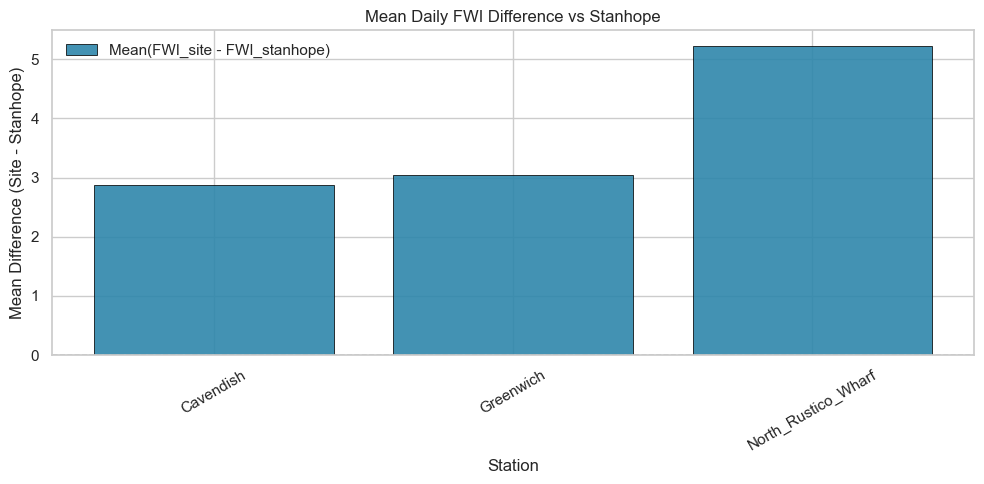

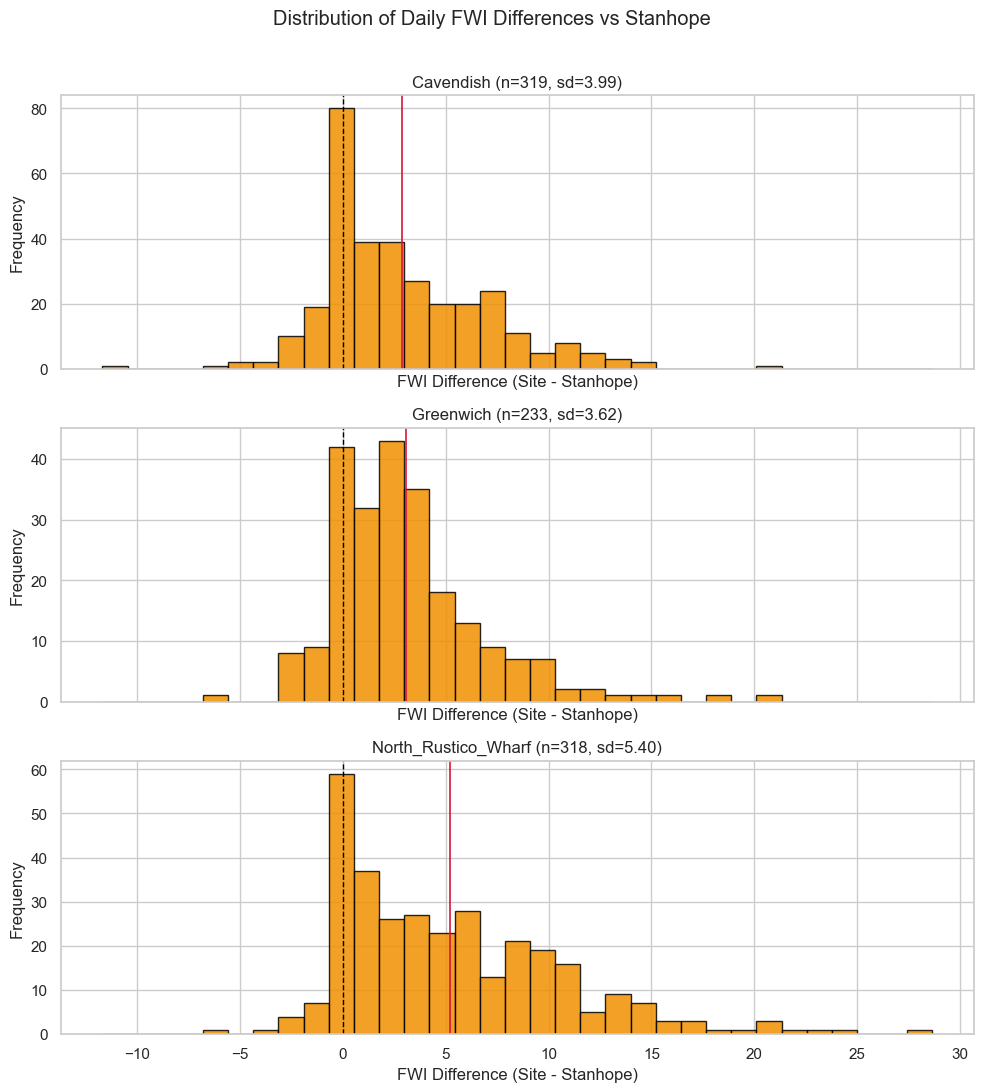

Saved summary table: c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\08_fwi_station_vs_stanhope_diff_summary.csv
Saved figure: c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\figures\08_fwi_mean_diff_vs_stanhope.png
Saved figure: c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\figures\08_fwi_diff_histograms_vs_stanhope.png
Saved FWI model and validation outputs.


In [8]:
# =============================================================================
# FWI MODELING + VALIDATION
# Purpose: compute daily FWI from hourly weather and validate vs ECCC references.
# =============================================================================

SEASON_MONTHS = {6, 7, 8, 9}
FFMC_START = 85.0
DMC_START = 6.0
DC_START = 15.0


def ffmc_code(temp_c: float, rh_pct: float, wind_kmh: float, rain_mm: float, ffmc_prev: float) -> float:
    """Compute Fine Fuel Moisture Code (FFMC) for one day using standard equations."""
    mo = 147.2 * (101 - ffmc_prev) / (59.5 + ffmc_prev)
    if rain_mm > 0.5:
        rf = rain_mm - 0.5
        if mo > 150:
            mo = mo + 42.5 * rf * math.exp(-100 / (251 - mo)) * (1 - math.exp(-6.93 / rf)) + 0.0015 * (mo - 150) ** 2 * rf ** 0.5
        else:
            mo = mo + 42.5 * rf * math.exp(-100 / (251 - mo)) * (1 - math.exp(-6.93 / rf))
        mo = min(mo, 250)
    ed = 0.942 * rh_pct**0.679 + 11 * math.exp((rh_pct - 100) / 10) + 0.18 * (21.1 - temp_c) * (1 - math.exp(-0.115 * rh_pct))
    ew = 0.618 * rh_pct**0.753 + 10 * math.exp((rh_pct - 100) / 10) + 0.18 * (21.1 - temp_c) * (1 - math.exp(-0.115 * rh_pct))
    if mo > ed:
        ko = 0.424 * (1 - (rh_pct / 100) ** 1.7) + 0.0694 * wind_kmh**0.5 * (1 - (rh_pct / 100) ** 8)
        kd = ko * 0.581 * math.exp(0.0365 * temp_c)
        m = ed + (mo - ed) * 10 ** (-kd)
    elif mo < ew:
        ko = 0.424 * (1 - ((100 - rh_pct) / 100) ** 1.7) + 0.0694 * wind_kmh**0.5 * (1 - ((100 - rh_pct) / 100) ** 8)
        kw = ko * 0.581 * math.exp(0.0365 * temp_c)
        m = ew - (ew - mo) * 10 ** (-kw)
    else:
        m = mo
    return 59.5 * (250 - m) / (147.2 + m)


def dmc_code(temp_c: float, rh_pct: float, rain_mm: float, dmc_prev: float, month: int) -> float:
    """Compute Duff Moisture Code (DMC) for one day."""
    day_length_factors = [6.5, 7.5, 9.0, 12.8, 13.9, 13.9, 12.4, 10.9, 9.4, 8.0, 7.8, 6.3]
    temp_c = max(temp_c, -1.1)
    rk = 1.894 * (temp_c + 1.1) * (100 - rh_pct) * day_length_factors[month - 1] * 1e-4
    if rain_mm > 1.5:
        rw = 0.92 * rain_mm - 1.27
        wmi = 20 + 280 / math.exp(0.023 * dmc_prev)
        if dmc_prev <= 33:
            b = 100 / (0.5 + 0.3 * dmc_prev)
        elif dmc_prev <= 65:
            b = 14 - 1.3 * math.log(dmc_prev)
        else:
            b = 6.2 * math.log(dmc_prev) - 17.2
        wmr = wmi + 1000 * rw / (48.77 + b * rw) if rw > 0 else wmi
        pr = 43.43 * (5.6348 - math.log(wmr - 20)) if wmr > 20 else 0.0
    else:
        pr = dmc_prev
    return max(pr, 0) + rk


def dc_code(temp_c: float, rain_mm: float, dc_prev: float, month: int) -> float:
    """Compute Drought Code (DC) for one day."""
    seasonal_factors = [-1.6, -1.6, -1.6, 0.9, 3.8, 5.8, 6.4, 5.0, 2.4, 0.4, -1.6, -1.6]
    temp_c = max(temp_c, -2.8)
    pe = max((0.36 * (temp_c + 2.8) + seasonal_factors[month - 1]) / 2, 0)
    if rain_mm > 2.8:
        rw = 0.83 * rain_mm - 1.27
        smi = 800 * math.exp(-dc_prev / 400)
        log_arg = 1 + 3.937 * rw / smi if smi > 0 else 1
        dr = dc_prev - 400 * math.log(log_arg) if log_arg > 0 else 0
        dr = max(dr, 0)
    else:
        dr = dc_prev
    return dr + pe


def isi_index(wind_kmh: float, ffmc_value: float) -> float:
    """Compute Initial Spread Index (ISI) from wind and FFMC."""
    fm = 147.2 * (101 - ffmc_value) / (59.5 + ffmc_value)
    sf = 19.115 * math.exp(-0.1386 * fm) * (1 + fm**5.31 / 4.93e7)
    return sf * math.exp(0.05039 * wind_kmh)


def bui_index(dmc_value: float, dc_value: float) -> float:
    """Compute Build-Up Index (BUI) from DMC and DC."""
    den = dmc_value + 0.4 * dc_value
    if den <= 0:
        return 0.0
    if dmc_value <= 0.4 * dc_value:
        return 0.8 * dmc_value * dc_value / den
    return max(dmc_value - (1 - 0.8 * dc_value / den) * (0.92 + (0.0114 * dmc_value) ** 1.7), 0)


def fwi_index(isi_value: float, bui_value: float) -> float:
    """Compute final Fire Weather Index (FWI) from ISI and BUI."""
    if bui_value <= 80:
        bb = 0.1 * isi_value * (0.626 * bui_value**0.809 + 2)
    else:
        bb = 0.1 * isi_value * (1000 / (25 + 108.64 * math.exp(-0.023 * bui_value)))
    return bb if bb <= 1 else math.exp(2.72 * (0.434 * math.log(bb)) ** 0.647)


# ---- Build local-time daily modeling frame from hourly inputs ----
s = hourly.copy()
s["datetime_local"] = s["datetime_utc"].dt.tz_convert(HALIFAX_TZ)
s["date_local"] = s["datetime_local"].dt.date
s["local_hour"] = s["datetime_local"].dt.hour
s = s[s["datetime_local"].dt.month.isin(SEASON_MONTHS)].copy()

# Extract noon observations used by FWI equations.
noon = s[s["local_hour"] == 12][["station_slug", "date_local", "datetime_local", "datetime_utc", *CORE_VARS]].copy()
noon = noon.rename(columns={
    "datetime_local": "datetime_noon_local",
    "datetime_utc": "datetime_noon_utc",
    "air_temperature_c": "air_temperature_c_noon",
    "relative_humidity_pct": "relative_humidity_pct_noon",
    "wind_speed_kmh": "wind_speed_kmh_noon",
})
noon["noon_core_present"] = noon[["air_temperature_c_noon", "relative_humidity_pct_noon", "wind_speed_kmh_noon"]].notna().all(axis=1)

# Compute rolling 24-hour precipitation total aligned to each local noon day.
precip_rows = []
for station_slug, g in s.groupby("station_slug", dropna=False):
    precip = g.set_index("datetime_utc")["precipitation_mm"].sort_index()
    for local_day in sorted(g["date_local"].unique().tolist()):
        start_local = datetime.combine(local_day - timedelta(days=1), datetime.min.time().replace(hour=13), tzinfo=HALIFAX_TZ)
        idx_local = pd.date_range(start=start_local, periods=24, freq="h", tz=HALIFAX_TZ)
        vals = precip.reindex(idx_local.tz_convert(timezone.utc))
        complete = int(vals.notna().sum()) == 24
        precip_rows.append(
            {
                "station_slug": station_slug,
                "date_local": local_day,
                "precip_window_complete_24h": complete,
                "precip_24h_sum_mm": float(vals.sum()) if complete else np.nan,
            }
        )
precip_daily = pd.DataFrame(precip_rows)

# Merge noon weather + precip window completeness into one daily modeling table.
daily = noon.merge(precip_daily, on=["station_slug", "date_local"], how="left")
daily = daily.sort_values(["station_slug", "date_local"]).reset_index(drop=True)

# Pre-allocate model output columns.
daily["ffmc"] = np.nan
daily["dmc"] = np.nan
daily["dc"] = np.nan
daily["isi"] = np.nan
daily["bui"] = np.nan
daily["fwi"] = np.nan
daily["segment_id"] = pd.Series(pd.NA, index=daily.index, dtype="string")
daily["continuity_gap_days"] = np.nan
daily["continuity_reset_applied"] = False

# ---- Sequential FWI calculation by station ----
# Important: FFMC/DMC/DC are stateful, so we iterate in date order.
for station_slug, idx in daily.groupby("station_slug", sort=False).groups.items():
    prev_day = None
    ffmc_prev, dmc_prev, dc_prev = FFMC_START, DMC_START, DC_START
    seg = 0
    for i in idx:
        row = daily.loc[i]
        # Skip days lacking core noon values or complete precip window.
        if not bool(row["noon_core_present"]) or not bool(row["precip_window_complete_24h"]):
            prev_day = None
            continue
        day = row["date_local"]
        gap = float((day - prev_day).days) if prev_day is not None else np.nan

        # Reset moisture-code state when continuity breaks (>1 day gap).
        if prev_day is None or (pd.notna(gap) and gap > 1):
            seg += 1
            ffmc_prev, dmc_prev, dc_prev = FFMC_START, DMC_START, DC_START
            reset = True
        else:
            reset = False

        # Input values for this day.
        t = float(row["air_temperature_c_noon"])
        rh = float(row["relative_humidity_pct_noon"])
        w = float(row["wind_speed_kmh_noon"])
        r = float(row["precip_24h_sum_mm"])
        month = int(pd.Timestamp(day).month)

        # Run one-step update across the FWI code chain.
        ffmc_prev = ffmc_code(t, rh, w, r, ffmc_prev)
        dmc_prev = dmc_code(t, rh, r, dmc_prev, month)
        dc_prev = dc_code(t, r, dc_prev, month)
        isi = isi_index(w, ffmc_prev)
        bui = bui_index(dmc_prev, dc_prev)
        fwi = fwi_index(isi, bui)

        # Persist results and continuity metadata.
        daily.loc[i, ["ffmc", "dmc", "dc", "isi", "bui", "fwi"]] = [ffmc_prev, dmc_prev, dc_prev, isi, bui, fwi]
        daily.loc[i, "segment_id"] = f"{pd.Timestamp(day).year}_{seg}"
        daily.loc[i, "continuity_gap_days"] = gap
        daily.loc[i, "continuity_reset_applied"] = reset
        prev_day = day

# Final modeled daily table export.
model_daily = daily[[
    "station_slug", "date_local", "air_temperature_c_noon", "relative_humidity_pct_noon", "wind_speed_kmh_noon", "precip_24h_sum_mm",
    "ffmc", "dmc", "dc", "isi", "bui", "fwi", "noon_core_present", "precip_window_complete_24h", "segment_id", "continuity_gap_days", "continuity_reset_applied"
]].copy()
model_daily.to_csv(TABLES_DIR / "04_model_fwi_daily.csv", index=False)

# ---- Optional validation against ECCC Stanhope daily FWI references ----
validation_rows = []
if REFERENCE_FWI_DIR.exists() and any(REFERENCE_FWI_DIR.glob("*.csv")):
    ref_frames = []
    for fp in sorted(REFERENCE_FWI_DIR.glob("*.csv")):
        df_ref = pd.read_csv(fp, low_memory=False)
        if all(c in df_ref.columns for c in ["Date", "FFMC", "DMC", "DC", "FWI"]):
            df_ref = df_ref[["Date", "FFMC", "DMC", "DC", "FWI"]].copy()
            df_ref["date_local"] = pd.to_datetime(df_ref["Date"], errors="coerce").dt.date
            ref_frames.append(df_ref.dropna(subset=["date_local"]))
    if ref_frames:
        ref = pd.concat(ref_frames, ignore_index=True).drop_duplicates(subset=["date_local"], keep="last")
        stanhope = model_daily[model_daily["station_slug"].astype(str).str.lower() == REFERENCE_STATION.lower()].copy()
        merged = stanhope.merge(ref, on="date_local", how="inner")
        for pred_col, ref_col in [("ffmc", "FFMC"), ("dmc", "DMC"), ("dc", "DC"), ("fwi", "FWI")]:
            valid = merged[pred_col].notna() & merged[ref_col].notna()
            xa = merged.loc[valid, pred_col].astype(float)
            xb = merged.loc[valid, ref_col].astype(float)
            validation_rows.append(
                {
                    "metric": pred_col,
                    "n": int(valid.sum()),
                    "mae": calc_mae(xa, xb),
                    "rmse": calc_rmse(xa, xb),
                    "bias": calc_bias(xa, xb),
                    "pearson_r": calc_corr(xa, xb, "pearson"),
                }
            )

validation_df = pd.DataFrame(validation_rows)
validation_df.to_csv(TABLES_DIR / "04_model_fwi_validation_summary.csv", index=False)

display(Markdown("### Fire Weather Index Output (Business Impact)"))
display(Markdown("These are the daily fire danger indicators used to inform readiness, staffing, and prevention messaging. Better agreement with ECCC means higher confidence in local operational use."))

fwi_snapshot = (
    model_daily.dropna(subset=["fwi"])
    .sort_values("date_local", ascending=False)
    [["station_slug", "date_local", "fwi", "ffmc", "dmc", "dc"]]
    .head(12)
    .rename(columns={
        "station_slug": "Station",
        "date_local": "Date",
        "fwi": "FWI",
        "ffmc": "FFMC",
        "dmc": "DMC",
        "dc": "DC",
    })
)
display(fwi_snapshot.round(2))

if not validation_df.empty:
    validation_view = validation_df.rename(columns={
        "metric": "Metric",
        "n": "Days Compared",
        "mae": "MAE",
        "rmse": "RMSE",
        "bias": "Bias",
        "pearson_r": "Pearson r",
    })
    display(Markdown("**Validation Against ECCC Stanhope**"))
    display(validation_view.round(3))
    fwi_row = validation_df[validation_df["metric"] == "fwi"]
    if not fwi_row.empty:
        r_val = float(fwi_row.iloc[0]["pearson_r"])
        rmse_val = float(fwi_row.iloc[0]["rmse"])
        confidence = "high" if r_val >= 0.85 else ("moderate" if r_val >= 0.70 else "low")
        display(Markdown(
            f"**Operational Confidence Signal:** FWI correlation to ECCC is {r_val:.3f} with RMSE {rmse_val:.3f}. "
            f"This suggests **{confidence}** confidence for using this pipeline in day-to-day fire danger planning."
        ))

# ---- FWI difference comparison vs Stanhope (moved from Cell 8) ----
fwi_source = model_daily.copy()
required_cols = {"station_slug", "date_local", "fwi"}
missing = required_cols.difference(fwi_source.columns)
if missing:
    raise ValueError(f"FWI comparison requires columns {required_cols}, missing: {sorted(missing)}")

fwi_df = fwi_source[["station_slug", "date_local", "fwi"]].copy()
fwi_df["station_slug"] = fwi_df["station_slug"].astype(str).str.strip()
fwi_df["date_local"] = pd.to_datetime(fwi_df["date_local"], errors="coerce")
fwi_df["fwi"] = pd.to_numeric(fwi_df["fwi"], errors="coerce")
fwi_df = fwi_df.dropna(subset=["station_slug", "date_local", "fwi"])

ref_slug = REFERENCE_STATION
stan = (
    fwi_df[fwi_df["station_slug"].str.lower() == str(ref_slug).lower()][["date_local", "fwi"]]
    .rename(columns={"fwi": "fwi_stanhope"})
    .drop_duplicates(subset=["date_local"])
    .sort_values("date_local")
)
if stan.empty:
    raise ValueError(f"No Stanhope/reference rows found in FWI data for '{ref_slug}'.")

sites = sorted(
    s for s in fwi_df["station_slug"].unique().tolist()
    if str(s).lower() != str(ref_slug).lower()
)

summary_rows = []
diffs_by_site = {}
for site in sites:
    site_daily = (
        fwi_df[fwi_df["station_slug"] == site][["date_local", "fwi"]]
        .rename(columns={"fwi": "fwi_site"})
        .drop_duplicates(subset=["date_local"])
        .sort_values("date_local")
    )
    merged = site_daily.merge(stan, on="date_local", how="inner")
    if merged.empty:
        continue

    merged["fwi_diff"] = merged["fwi_site"] - merged["fwi_stanhope"]
    diffs = merged["fwi_diff"].dropna()
    if diffs.empty:
        continue

    diffs_by_site[site] = diffs
    summary_rows.append(
        {
            "station_slug": site,
            "n_aligned_days": int(diffs.shape[0]),
            "mean_diff_site_minus_stanhope": float(diffs.mean()),
            "median_diff_site_minus_stanhope": float(diffs.median()),
            "mean_abs_diff": float(diffs.abs().mean()),
            "rmse": float(np.sqrt(np.mean(np.square(diffs)))),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("mean_diff_site_minus_stanhope")
if summary_df.empty:
    raise ValueError("No aligned station-vs-Stanhope FWI days found to compare.")

display(Markdown("### FWI Mean Difference vs Stanhope"))
display(summary_df.round(3))

fwi_diff_table_path = TABLES_DIR / "08_fwi_station_vs_stanhope_diff_summary.csv"
fwi_diff_table_path.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(fwi_diff_table_path, index=False)

fig, ax = plt.subplots(figsize=(10, 5))
bar_data = summary_df.sort_values("mean_diff_site_minus_stanhope")
ax.bar(
    bar_data["station_slug"],
    bar_data["mean_diff_site_minus_stanhope"],
    color="#2E86AB",
    alpha=0.9,
    edgecolor="black",
    linewidth=0.6,
    label="Mean(FWI_site - FWI_stanhope)",
)
ax.axhline(0, color="black", linestyle="--", linewidth=1.0)
ax.set_title("Mean Daily FWI Difference vs Stanhope")
ax.set_xlabel("Station")
ax.set_ylabel("Mean Difference (Site - Stanhope)")
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="best", frameon=False)
fig.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
mean_diff_fig_path = FIGURES_DIR / "08_fwi_mean_diff_vs_stanhope.png"
fig.savefig(mean_diff_fig_path, dpi=180)
plt.show()
plt.close(fig)

all_diffs = np.concatenate([v.to_numpy(dtype=float) for v in diffs_by_site.values()])
bins = np.histogram_bin_edges(all_diffs, bins="auto")

def _hist_sort_key(item):
    site_name = str(item[0]).strip().lower()
    return ("north rustico" in site_name, site_name)

ordered_sites = sorted(diffs_by_site.items(), key=_hist_sort_key)
n_sites = len(ordered_sites)
fig, axes = plt.subplots(n_sites, 1, figsize=(10, 3.6 * n_sites), sharex=True, sharey=False)
axes = np.atleast_1d(axes).ravel()

for i, (site, diffs) in enumerate(ordered_sites):
    ax = axes[i]
    ax.hist(diffs.to_numpy(dtype=float), bins=bins, color="#F18F01", edgecolor="black", alpha=0.85)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
    ax.axvline(diffs.mean(), color="crimson", linestyle="-", linewidth=1.2)
    std_val = float(diffs.std(ddof=1)) if len(diffs) > 1 else 0.0
    ax.set_title(f"{site} (n={len(diffs)}, sd={std_val:.2f})")
    ax.set_xlabel("FWI Difference (Site - Stanhope)")
    ax.set_ylabel("Frequency")

fig.suptitle("Distribution of Daily FWI Differences vs Stanhope", y=1.01)
fig.tight_layout()
hist_fig_path = FIGURES_DIR / "08_fwi_diff_histograms_vs_stanhope.png"
fig.savefig(hist_fig_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved summary table: {fwi_diff_table_path}")
print(f"Saved figure: {mean_diff_fig_path}")
print(f"Saved figure: {hist_fig_path}")

print("Saved FWI model and validation outputs.")

**Expected Output (Cell 9)**
- Saves daily modeled FWI results and validation summary CSVs to `outputs/tables`.
- Displays recent FWI snapshot and, when available, validation metrics vs ECCC Stanhope.
- Prints `Saved FWI model and validation outputs.` at completion.

In [9]:
# =============================================================================
# REDUNDANCY MODELING (PART 1/4): VALIDATION + WINDOW CONSTRUCTION
# Purpose: fail-fast checks and window tagging for station-level redundancy work.
# =============================================================================

required_columns = [
    "datetime_utc",
    "station_slug",
    "air_temperature_c",
    "relative_humidity_pct",
    "wind_speed_kmh",
    "precipitation_mm",
]
missing_columns = [c for c in required_columns if c not in hourly.columns]
if missing_columns:
    fail(f"Missing required columns for station-level redundancy modeling: {missing_columns}")

if hourly.duplicated(subset=["station_slug", "datetime_utc"]).any():
    n_dup = int(hourly.duplicated(subset=["station_slug", "datetime_utc"]).sum())
    fail(f"Found {n_dup} duplicate (station_slug, datetime_utc) rows.")

if not isinstance(hourly["datetime_utc"].dtype, pd.DatetimeTZDtype):
    fail("datetime_utc must be timezone-aware.")

dt_tz = str(hourly["datetime_utc"].dt.tz)
if dt_tz not in {"UTC", "UTC+00:00"}:
    fail(f"datetime_utc must be UTC; detected timezone '{dt_tz}'.")

redundancy_hourly = hourly[required_columns].copy()

# Optional QC handling: treat QC-failed values as missing before station aggregation.
for var_name in ["air_temperature_c", "relative_humidity_pct", "wind_speed_kmh", "precipitation_mm"]:
    qc_col = f"{var_name}_failed_qc"
    if qc_col in hourly.columns:
        failed_mask = hourly[qc_col].fillna(False).astype(bool)
        redundancy_hourly.loc[failed_mask, var_name] = np.nan

local_ts = redundancy_hourly["datetime_utc"].dt.tz_convert("America/Halifax")
month = local_ts.dt.month
day = local_ts.dt.day

season_map = {12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring", 6: "summer", 7: "summer", 8: "summer", 9: "fall", 10: "fall", 11: "fall"}
redundancy_hourly["season"] = month.map(season_map).astype(str)
redundancy_hourly["is_fwi_season"] = (
    ((month > 6) & (month < 9))
    | ((month == 6) & (day >= 1))
    | ((month == 9) & (day <= 30))
)

overall_window = redundancy_hourly.assign(window="overall")
season_window = redundancy_hourly.assign(window=redundancy_hourly["season"])
fwi_window = redundancy_hourly[redundancy_hourly["is_fwi_season"]].assign(window="fwi_season")

redundancy_hourly = pd.concat([overall_window, season_window, fwi_window], ignore_index=True)
redundancy_hourly = redundancy_hourly.drop(columns=["season", "is_fwi_season"] )

display(Markdown("### Redundancy Window Coverage"))
coverage = (
    redundancy_hourly.groupby(["window", "station_slug"], dropna=False)
    .size()
    .reset_index(name="n_hours")
    .sort_values(["window", "station_slug"])
)
display(coverage.head(20))

window_station_counts = (
    coverage.groupby("window", dropna=False)["station_slug"]
    .nunique()
    .reset_index(name="n_stations")
    .sort_values("window")
)

display(Markdown("### Business Impact (Part 1)"))
display(Markdown(
    "We first make sure the data is clean and complete enough to trust. "
    "Then we group records into useful time windows. "
    "This protects the final station decision from bad input data."
))
display(window_station_counts)
print("Part 1 complete: data check and window setup finished.")

### Redundancy Window Coverage

,window,station_slug,n_hours
0,fall,Cavendish,7025
1,fall,Greenwich,7432
2,fall,North_Rustico_Wharf,6555
3,fall,Stanhope,8740
4,fall,Stanley_Bridge_Wharf,8740
5,fall,Tracadie_Wharf,6555
6,fwi_season,Cavendish,8784
7,fwi_season,Greenwich,8784
8,fwi_season,North_Rustico_Wharf,8784
9,fwi_season,Stanhope,11712


### Business Impact (Part 1)

We first make sure the data is clean and complete enough to trust. Then we group records into useful time windows. This protects the final station decision from bad input data.

,window,n_stations
0,fall,6
1,fwi_season,6
2,overall,6
3,spring,6
4,summer,6
5,winter,6


Part 1 complete: data check and window setup finished.


**Expected Output (Part 1: Data Check and Time Windows)**
- Shows coverage by station and time window.
- Shows number of stations in each window.
- Shows a short business note about why this check matters.
- Prints: Part 1 complete: data check and window setup finished.

In [10]:
# =============================================================================
# REDUNDANCY MODELING (PART 2/4): STATION FEATURE ENGINEERING + DATA GATING
# Purpose: aggregate hourly weather to station-level vectors per window.
# =============================================================================

CORE_REDUNDANCY_VARS = [
    "air_temperature_c",
    "relative_humidity_pct",
    "wind_speed_kmh",
    "precipitation_mm",
]

MIN_HOURS_PER_WINDOW = 500
MIN_COMPLETE_CASE_FRACTION = 0.60

def _series_stats(series: pd.Series) -> dict:
    s = series.dropna().astype(float)
    if s.empty:
        return {
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "p10": np.nan,
            "p90": np.nan,
            "iqr": np.nan,
        }
    return {
        "mean": float(s.mean()),
        "median": float(s.median()),
        "std": float(s.std(ddof=1)) if len(s) > 1 else 0.0,
        "p10": float(s.quantile(0.10)),
        "p90": float(s.quantile(0.90)),
        "iqr": float(s.quantile(0.75) - s.quantile(0.25)),
    }

def _precip_stats(series: pd.Series) -> dict:
    s = series.dropna().astype(float)
    if s.empty:
        return {
            "mean": np.nan,
            "std": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "max": np.nan,
            "fraction_zero": np.nan,
            "mean_positive": np.nan,
        }
    positive = s[s > 0]
    return {
        "mean": float(s.mean()),
        "std": float(s.std(ddof=1)) if len(s) > 1 else 0.0,
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "max": float(s.max()),
        "fraction_zero": float((s == 0).mean()),
        "mean_positive": float(positive.mean()) if len(positive) > 0 else 0.0,
    }

feature_rows = []
for (window_name, station_slug), g in redundancy_hourly.groupby(["window", "station_slug"], dropna=False):
    row = {
        "window": str(window_name),
        "station_slug": str(station_slug),
        "n_hours_total": int(len(g)),
    }

    complete_case_mask = g[CORE_REDUNDANCY_VARS].notna().all(axis=1)
    row["n_hours_complete_case"] = int(complete_case_mask.sum())
    row["complete_case_fraction"] = (
        float(row["n_hours_complete_case"] / row["n_hours_total"])
        if row["n_hours_total"] > 0
        else np.nan
    )

    for var_name in ["air_temperature_c", "relative_humidity_pct", "wind_speed_kmh"]:
        stats = _series_stats(g[var_name])
        row[f"{var_name}_mean"] = stats["mean"]
        row[f"{var_name}_median"] = stats["median"]
        row[f"{var_name}_std"] = stats["std"]
        row[f"{var_name}_p10"] = stats["p10"]
        row[f"{var_name}_p90"] = stats["p90"]
        row[f"{var_name}_iqr"] = stats["iqr"]

    precip = _precip_stats(g["precipitation_mm"])
    row["precipitation_mm_mean"] = precip["mean"]
    row["precipitation_mm_std"] = precip["std"]
    row["precipitation_mm_p95"] = precip["p95"]
    row["precipitation_mm_p99"] = precip["p99"]
    row["precipitation_mm_max"] = precip["max"]
    row["precipitation_mm_fraction_zero"] = precip["fraction_zero"]
    row["precipitation_mm_mean_positive"] = precip["mean_positive"]

    status_ok = (
        row["n_hours_total"] >= MIN_HOURS_PER_WINDOW
        and pd.notna(row["complete_case_fraction"])
        and row["complete_case_fraction"] >= MIN_COMPLETE_CASE_FRACTION
    )
    row["status"] = "ok" if status_ok else "skipped_insufficient_data"
    feature_rows.append(row)

station_feature_vectors = pd.DataFrame(feature_rows).sort_values(["window", "station_slug"]).reset_index(drop=True)

# Enforce complete-case across engineered PCA feature inputs.
metadata_columns = [
    "window",
    "station_slug",
    "n_hours_total",
    "n_hours_complete_case",
    "complete_case_fraction",
    "status",
]
pca_feature_columns = [c for c in station_feature_vectors.columns if c not in metadata_columns]
has_missing_pca_features = station_feature_vectors[pca_feature_columns].isna().any(axis=1)
station_feature_vectors.loc[
    (station_feature_vectors["status"] == "ok") & has_missing_pca_features,
    "status",
] = "skipped_incomplete_features"

station_feature_vectors.to_csv(TABLES_DIR / "05_model_station_feature_vectors.csv", index=False)

display(Markdown("### Station-Level Feature Vectors (Preview)"))
display(station_feature_vectors.head(12))
display(Markdown(
    f"Gating thresholds: `MIN_HOURS_PER_WINDOW={MIN_HOURS_PER_WINDOW}`, "
    f"`MIN_COMPLETE_CASE_FRACTION={MIN_COMPLETE_CASE_FRACTION}`."
))

status_summary = (
    station_feature_vectors.groupby(["window", "status"], dropna=False)
    .size()
    .reset_index(name="n_station_vectors")
    .sort_values(["window", "status"])
)

display(Markdown("### Business Impact (Part 2)"))
display(Markdown(
    "Here we create a simple profile for each station. "
    "We also flag stations that do not have enough good data. "
    "That helps you avoid making decisions based on weak evidence."
))
display(status_summary)
print("Part 2 complete: station profiles built and data-quality status set.")

### Station-Level Feature Vectors (Preview)

,window,station_slug,n_hours_total,n_hours_complete_case,complete_case_fraction,air_temperature_c_mean,air_temperature_c_median,air_temperature_c_std,air_temperature_c_p10,air_temperature_c_p90,...,wind_speed_kmh_p90,wind_speed_kmh_iqr,precipitation_mm_mean,precipitation_mm_std,precipitation_mm_p95,precipitation_mm_p99,precipitation_mm_max,precipitation_mm_fraction_zero,precipitation_mm_mean_positive,status
0,fall,Cavendish,7025,6305,0.897509,10.388319,11.010667,6.399510,1.725867,18.295867,...,26.120154,11.132551,0.115813,0.614652,0.6,2.6,14.0,0.899286,1.149921,ok
1,fall,Greenwich,7432,4370,0.587998,10.287323,10.298749,6.316861,2.048542,18.544175,...,19.918330,9.364121,0.085552,0.421699,0.4,1.8,10.2,0.889279,0.772683,skipped_insufficient_data
2,fall,North_Rustico_Wharf,6555,6373,0.972235,10.955817,11.510000,6.497775,2.336013,19.236921,...,28.812680,14.606775,0.085919,0.536812,0.4,2.0,22.4,0.912891,0.986340,ok
3,fall,Stanhope,8740,8249,0.943822,10.800553,11.500000,6.534425,1.900000,18.900000,...,24.000000,10.000000,0.133236,0.686058,0.6,3.2,14.6,0.887677,1.186192,ok
4,fall,Stanley_Bridge_Wharf,8740,0,0.000000,11.105188,11.584333,6.364307,2.422133,18.988800,...,31.372832,14.871936,0.096323,0.446028,0.6,2.0,9.2,0.894432,0.912428,skipped_insufficient_data
5,fall,Tracadie_Wharf,6555,0,0.000000,10.152482,10.337834,6.487461,1.898667,18.724000,...,38.876236,17.417056,0.085128,0.497730,0.4,2.0,14.0,0.904144,0.888081,skipped_insufficient_data
6,fwi_season,Cavendish,8784,8050,0.916439,18.643977,18.601833,4.863363,12.537000,25.085833,...,21.546873,8.794131,0.069072,0.418730,0.2,1.8,8.8,0.937996,1.114000,ok
7,fwi_season,Greenwich,8784,5842,0.665073,18.770773,18.631292,4.821211,12.752834,25.259625,...,18.477695,7.933926,0.044422,0.278295,0.2,1.0,7.0,0.939663,0.736226,ok
8,fwi_season,North_Rustico_Wharf,8784,8042,0.915528,18.429736,18.680166,4.699640,11.843197,24.367950,...,26.933592,12.151433,0.075592,0.553696,0.2,2.2,22.4,0.946494,1.412766,ok
9,fwi_season,Stanhope,11712,11635,0.993426,18.142368,18.300000,4.634025,11.900000,24.000000,...,20.000000,7.000000,0.109739,0.690673,0.3,3.1,18.7,0.935791,1.709079,ok


Gating thresholds: `MIN_HOURS_PER_WINDOW=500`, `MIN_COMPLETE_CASE_FRACTION=0.6`.

### Business Impact (Part 2)

Here we create a simple profile for each station. We also flag stations that do not have enough good data. That helps you avoid making decisions based on weak evidence.

,window,status,n_station_vectors
0,fall,ok,3
1,fall,skipped_insufficient_data,3
2,fwi_season,ok,4
3,fwi_season,skipped_insufficient_data,2
4,overall,ok,3
5,overall,skipped_insufficient_data,3
6,spring,ok,3
7,spring,skipped_insufficient_data,3
8,summer,ok,4
9,summer,skipped_insufficient_data,2


Part 2 complete: station profiles built and data-quality status set.


**Expected Output (Part 2: Station Profiles and Data Quality Status)**
- Shows a preview of station profiles.
- Shows status by window so you can see which stations have enough data.
- Shows a short business note about decision confidence.
- Prints: Part 2 complete: station profiles built and data-quality status set.

In [11]:
# =============================================================================
# REDUNDANCY MODELING (PART 3/4): STATION-LEVEL PCA
# Purpose: model overlap across stations (not hourly rows) for each window.
# =============================================================================

pca_explained_rows = []
pca_loading_rows = []
pca_score_rows = []

# Strictly exclude metadata columns to avoid leakage from uptime/coverage.
metadata_columns = [
    "window",
    "station_slug",
    "n_hours_total",
    "n_hours_complete_case",
    "complete_case_fraction",
    "status",
]
pca_input_features = [c for c in station_feature_vectors.columns if c not in metadata_columns]

if len(pca_input_features) == 0:
    fail("No station-level PCA features were engineered.")

for window_name in ["overall", "winter", "spring", "summer", "fall", "fwi_season"]:
    win = station_feature_vectors[station_feature_vectors["window"] == window_name].copy()
    if win.empty:
        continue

    eligible = win[win["status"] == "ok"].copy()
    n_stations_ok = len(eligible)

    if n_stations_ok < 2:
        continue

    X = eligible[pca_input_features].to_numpy(dtype=float)
    if not np.isfinite(X).all():
        fail(f"Non-finite station PCA inputs for window '{window_name}'.")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    if not np.isfinite(X_scaled).all():
        fail(f"Non-finite scaled PCA inputs for window '{window_name}'.")

    n_components = min(len(pca_input_features), max(1, n_stations_ok - 1))
    pca_station = PCA(n_components=n_components, random_state=RANDOM_SEED)
    scores = pca_station.fit_transform(X_scaled)

    cumulative = np.cumsum(pca_station.explained_variance_ratio_)
    for i in range(n_components):
        pca_explained_rows.append({
            "window": window_name,
            "component": f"PC{i + 1}",
            "explained_variance_ratio": float(pca_station.explained_variance_ratio_[i]),
            "explained_variance_cumulative": float(cumulative[i]),
            "n_stations_ok": int(n_stations_ok),
            "n_features": int(len(pca_input_features)),
        })

    for i in range(n_components):
        for feature_name, loading_value in zip(pca_input_features, pca_station.components_[i]):
            pca_loading_rows.append({
                "window": window_name,
                "component": f"PC{i + 1}",
                "variable": feature_name,
                "loading": float(loading_value),
            })

    for row_i, station_slug in enumerate(eligible["station_slug"].astype(str).tolist()):
        row = {"window": window_name, "station_slug": station_slug}
        for pc_i in range(n_components):
            row[f"PC{pc_i + 1}"] = float(scores[row_i, pc_i])
        pca_score_rows.append(row)

pca_station_explained = pd.DataFrame(pca_explained_rows)
pca_station_loadings = pd.DataFrame(pca_loading_rows)
station_pca_scores = pd.DataFrame(pca_score_rows)

pca_station_explained.to_csv(TABLES_DIR / "05_model_pca_station_explained_variance.csv", index=False)
pca_station_loadings.to_csv(TABLES_DIR / "05_model_pca_station_loadings.csv", index=False)
station_pca_scores.to_csv(TABLES_DIR / "05_model_pca_station_scores.csv", index=False)

# Overall-window biplot is only valid when at least two retained components exist.
overall_scores = station_pca_scores[station_pca_scores["window"] == "overall"].copy()
overall_has_pc2 = "PC2" in overall_scores.columns and overall_scores["PC2"].notna().any()

if len(overall_scores) >= 2 and overall_has_pc2:
    overall_loadings = pca_station_loadings[
        (pca_station_loadings["window"] == "overall")
        & (pca_station_loadings["component"].isin(["PC1", "PC2"]))
    ].copy()

    plt.figure(figsize=(9, 7))
    plt.axhline(0, linewidth=0.8, color="gray", alpha=0.5)
    plt.axvline(0, linewidth=0.8, color="gray", alpha=0.5)

    for station_slug, g in overall_scores.groupby("station_slug", dropna=False):
        plt.scatter(g["PC1"], g["PC2"], s=60, alpha=0.9, label=station_slug)
        plt.text(float(g["PC1"].iloc[0]), float(g["PC2"].iloc[0]), str(station_slug), fontsize=9)

    loading_matrix = overall_loadings.pivot(index="variable", columns="component", values="loading").reset_index().fillna(0.0)
    score_span = np.nanmax(np.abs(overall_scores[["PC1", "PC2"]].to_numpy(dtype=float)))
    arrow_scale = 0.85 * score_span if np.isfinite(score_span) and score_span > 0 else 1.0

    for _, row in loading_matrix.iterrows():
        x = float(row.get("PC1", 0.0)) * arrow_scale
        y = float(row.get("PC2", 0.0)) * arrow_scale
        plt.arrow(0, 0, x, y, color="black", alpha=0.7, head_width=0.03)
        plt.text(x * 1.05, y * 1.05, str(row["variable"]), fontsize=8)

    plt.title("Station-Level PCA Biplot (Overall Window)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_model_pca_station_biplot_overall.png", dpi=180)
    plt.close()
else:
    print("Overall window has <2 PCs available; skipped station biplot.")

display(Markdown("### Business Impact (Part 3)"))
display(Markdown(
    "This step gives each station a small set of easy comparison scores. "
    "If stations sit close together, they likely tell the same weather story. "
    "That can support reducing overlap."
))
if not pca_station_explained.empty:
    display(pca_station_explained.head(12))
print("Part 3 complete: station comparison scores saved.")

### Business Impact (Part 3)

This step gives each station a small set of easy comparison scores. If stations sit close together, they likely tell the same weather story. That can support reducing overlap.

,window,component,explained_variance_ratio,explained_variance_cumulative,n_stations_ok,n_features
0,overall,PC1,0.831179,0.831179,3,25
1,overall,PC2,0.168821,1.000000,3,25
2,winter,PC1,0.699901,0.699901,3,25
3,winter,PC2,0.300099,1.000000,3,25
4,spring,PC1,0.728704,0.728704,3,25
5,spring,PC2,0.271296,1.000000,3,25
6,summer,PC1,0.555211,0.555211,4,25
7,summer,PC2,0.353780,0.908991,4,25
8,summer,PC3,0.091009,1.000000,4,25
9,fall,PC1,0.726870,0.726870,3,25


Part 3 complete: station comparison scores saved.


**Expected Output (Part 3: Station Comparison Scores)**
- Saves PCA score tables for station comparison.
- Shows a short business note that explains what close vs far stations mean.
- Shows a preview of explained variance when available.
- Prints: Part 3 complete: station comparison scores saved.

In [12]:
# =============================================================================
# REDUNDANCY MODELING (PART 4/4): STATION OVERLAP DISTANCES + BUSINESS SUMMARY
# Purpose: replace clustering with robust pairwise station overlap metrics.
# =============================================================================

display(Markdown("### Why K-Means Was Dropped"))
display(Markdown(
    "K-Means can be unreliable when we only have a few stations. "
    "It may create groups that look clear but are not stable. "
    "Distance between stations is simpler and easier to trust for this network."
))

# Disable inline figure display by default to reduce notebook memory pressure during Run All.
DISPLAY_FIGURES_INLINE = False

distance_rows = []
nearest_rows = []

for window_name, score_win in station_pca_scores.groupby("window", dropna=False):
    candidate_pc_columns = sorted([c for c in score_win.columns if c.startswith("PC")], key=lambda s: int(s.replace("PC", "")))
    pc_columns = [c for c in candidate_pc_columns if score_win[c].notna().all()]
    if len(pc_columns) == 0:
        continue

    score_win = score_win.dropna(subset=pc_columns).sort_values("station_slug").reset_index(drop=True)
    if len(score_win) < 2:
        continue

    station_labels = score_win["station_slug"].astype(str).tolist()
    coord = score_win[pc_columns].to_numpy(dtype=float)

    if not np.isfinite(coord).all():
        fail(f"Non-finite PCA coordinates found for window '{window_name}'.")

    diff = coord[:, None, :] - coord[None, :, :]
    dist_matrix = np.sqrt(np.sum(diff ** 2, axis=2))

    if not np.allclose(dist_matrix, dist_matrix.T, atol=1e-10):
        fail(f"Distance matrix is not symmetric for window '{window_name}'.")
    if not np.allclose(np.diag(dist_matrix), 0.0, atol=1e-10):
        fail(f"Distance matrix diagonal is not zero for window '{window_name}'.")

    for i, station_a in enumerate(station_labels):
        neighbor_distances = []
        for j, station_b in enumerate(station_labels):
            distance_value = float(dist_matrix[i, j])
            distance_rows.append({
                "window": window_name,
                "station_slug_a": station_a,
                "station_slug_b": station_b,
                "distance_euclidean": distance_value,
                "n_pcs_used": len(pc_columns),
            })
            if i != j:
                neighbor_distances.append((station_b, distance_value))

        if neighbor_distances:
            nearest_station, nearest_distance = sorted(neighbor_distances, key=lambda x: x[1])[0]
            nearest_rows.append({
                "window": window_name,
                "station_slug": station_a,
                "nearest_station_slug": nearest_station,
                "nearest_distance_euclidean": float(nearest_distance),
                "n_pcs_used": len(pc_columns),
            })

station_overlap_distances = pd.DataFrame(distance_rows)
station_nearest_neighbors = pd.DataFrame(nearest_rows)

station_overlap_distances.to_csv(TABLES_DIR / "05_model_station_overlap_distances.csv", index=False)
station_nearest_neighbors.to_csv(TABLES_DIR / "05_model_station_nearest_neighbors.csv", index=False)

display(Markdown("### Station Overlap Distances (Preview)"))
display(station_nearest_neighbors.sort_values(["window", "nearest_distance_euclidean"]).head(20))

# -----------------------------------------------------------------------------
# Requested visualization: 2x2 nearest-distance comparison bar charts
# Top row: Cavendish, Bottom row: Greenwich
# Left column: overall, Right column: fwi_season
# Bars are ordered highest (left) to lowest (right).
# -----------------------------------------------------------------------------
panel_stations = ["Cavendish", "Greenwich"]
panel_windows = ["overall", "fwi_season"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)

for row_idx, station_name in enumerate(panel_stations):
    for col_idx, window_name in enumerate(panel_windows):
        ax = axes[row_idx, col_idx]
        panel_df = station_overlap_distances[
            (station_overlap_distances["station_slug_a"] == station_name)
            & (station_overlap_distances["window"] == window_name)
            & (station_overlap_distances["station_slug_b"] != station_name)
        ].copy()

        if panel_df.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=11)
            ax.set_title(f"{station_name} | {window_name}")
            ax.set_xlabel("Other Station")
            ax.set_ylabel("Nearest Distance")
            ax.set_ylim(bottom=0)
            continue

        panel_df = panel_df.sort_values("distance_euclidean", ascending=False)
        x_labels = panel_df["station_slug_b"].astype(str).tolist()
        y_vals = panel_df["distance_euclidean"].astype(float).tolist()

        ax.bar(x_labels, y_vals, color="#2E86AB", edgecolor="black", linewidth=0.6)
        ax.set_title(f"{station_name} | {window_name}")
        ax.set_xlabel("Other Station")
        ax.set_ylabel("Nearest Distance")
        ax.set_ylim(bottom=0)  # 0 means identical; axis is unbounded upward in concept.
        ax.tick_params(axis="x", rotation=25)
        ax.text(
            0.02, 0.95, "Range: 0 (identical) to infinity",
            transform=ax.transAxes, va="top", fontsize=9, color="dimgray"
        )

fig.suptitle("Nearest Distance Comparison", fontsize=14, y=1.02)
fig.tight_layout()

panel_figure_path = FIGURES_DIR / "05_model_station_nearest_distance_panel_2x2.png"
fig.savefig(panel_figure_path, dpi=180, bbox_inches="tight")
if DISPLAY_FIGURES_INLINE:
    plt.show()
plt.close(fig)

display(Markdown("### Business Impact (Part 4)"))
display(Markdown(
    "This step shows which stations are most alike. "
    "Small distance means two stations are very similar. "
    "Large distance means a station may be capturing unique local weather."
))
if not station_nearest_neighbors.empty:
    closest_pair = station_nearest_neighbors.sort_values("nearest_distance_euclidean").iloc[0]
    display(Markdown(
        f"Closest pair this run: **{closest_pair['station_slug']}** and "
        f"**{closest_pair['nearest_station_slug']}** in **{closest_pair['window']}**."
    ))

print("Part 4 complete: overlap distances and nearest-station table saved.")
print("Generated redundancy artifacts:")
print(" -", TABLES_DIR / "05_model_station_feature_vectors.csv")
print(" -", TABLES_DIR / "05_model_pca_station_explained_variance.csv")
print(" -", TABLES_DIR / "05_model_pca_station_loadings.csv")
print(" -", TABLES_DIR / "05_model_pca_station_scores.csv")
print(" -", TABLES_DIR / "05_model_station_overlap_distances.csv")
print(" -", TABLES_DIR / "05_model_station_nearest_neighbors.csv")
print(" -", FIGURES_DIR / "05_model_pca_station_biplot_overall.png")
print(" -", panel_figure_path)

### Why K-Means Was Dropped

K-Means can be unreliable when we only have a few stations. It may create groups that look clear but are not stable. Distance between stations is simpler and easier to trust for this network.

### Station Overlap Distances (Preview)

,window,station_slug,nearest_station_slug,nearest_distance_euclidean,n_pcs_used
0,fall,Cavendish,Stanhope,6.671385,2
2,fall,Stanhope,Cavendish,6.671385,2
1,fall,North_Rustico_Wharf,Cavendish,8.784172,2
3,fwi_season,Cavendish,North_Rustico_Wharf,6.575566,3
5,fwi_season,North_Rustico_Wharf,Cavendish,6.575566,3
4,fwi_season,Greenwich,Cavendish,6.783950,3
6,fwi_season,Stanhope,Cavendish,7.054506,3
7,overall,Cavendish,North_Rustico_Wharf,6.510028,2
8,overall,North_Rustico_Wharf,Cavendish,6.510028,2
9,overall,Stanhope,Cavendish,7.672195,2


### Business Impact (Part 4)

This step shows which stations are most alike. Small distance means two stations are very similar. Large distance means a station may be capturing unique local weather.

Closest pair this run: **Cavendish** and **North_Rustico_Wharf** in **summer**.

Part 4 complete: overlap distances and nearest-station table saved.
Generated redundancy artifacts:
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\05_model_station_feature_vectors.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\05_model_pca_station_explained_variance.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\05_model_pca_station_loadings.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\05_model_pca_station_scores.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\05_model_station_overlap_distances.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\05_model_station_nearest_neighbors.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced

In [13]:
# =============================================================================
# CLOSEST-PAIR VARIABLE DIFFERENCE HISTOGRAMS (OVERALL WINDOW)
# Purpose: find the closest overall station pair and visualize variable differences.
# =============================================================================

# Disable inline figure display by default to reduce notebook memory pressure during Run All.
DISPLAY_FIGURES_INLINE = False

if "station_nearest_neighbors" not in globals() or "hourly" not in globals():
    raise ValueError(
        "This cell requires outputs from earlier cells. Run Cell 5 and Cell 24 first."
    )

overall_nearest = station_nearest_neighbors[
    station_nearest_neighbors["window"].astype(str).str.lower() == "overall"
].copy()

if overall_nearest.empty:
    raise ValueError("No nearest-neighbor rows found for the overall window.")

closest_overall = overall_nearest.sort_values("nearest_distance_euclidean", ascending=True).iloc[0]
station_a = str(closest_overall["station_slug"])

station_b = str(closest_overall["nearest_station_slug"])

closest_distance = float(closest_overall["nearest_distance_euclidean"])

station_a_label = station_a.replace("_", " ")
station_b_label = station_b.replace("_", " ")
print(f"Selected closest overall pair: {station_a_label} vs {station_b_label} (distance={closest_distance:.4f})")

cols_needed = [
    "datetime_utc",
    "station_slug",
    "air_temperature_c",
    "precipitation_mm",
    "relative_humidity_pct",
    "wind_speed_kmh",
    "wind_direction_deg",
]

pair_df = hourly[hourly["station_slug"].isin([station_a, station_b])][cols_needed].copy()
a_df = pair_df[pair_df["station_slug"] == station_a].drop(columns=["station_slug"])

b_df = pair_df[pair_df["station_slug"] == station_b].drop(columns=["station_slug"])

merged = a_df.merge(b_df, on="datetime_utc", how="inner", suffixes=("_a", "_b"))

if merged.empty:
    raise ValueError("No aligned hourly rows found for the selected station pair.")

# Difference convention: station_a minus station_b.
merged["temp_diff_c"] = merged["air_temperature_c_a"] - merged["air_temperature_c_b"]
merged["rh_diff_pct"] = merged["relative_humidity_pct_a"] - merged["relative_humidity_pct_b"]
merged["wind_speed_diff_kmh"] = merged["wind_speed_kmh_a"] - merged["wind_speed_kmh_b"]

# Circular wind-direction difference in [-180, 180] degrees.
merged["wind_direction_diff_deg"] = (
    (merged["wind_direction_deg_a"] - merged["wind_direction_deg_b"] + 180.0) % 360.0
    - 180.0
)

# Precipitation is aggregated to daily accumulation before differencing.
pair_precip = pair_df[["datetime_utc", "station_slug", "precipitation_mm"]].copy()
pair_precip["local_date"] = pair_precip["datetime_utc"].dt.tz_convert(HALIFAX_TZ).dt.date
daily_precip = (
    pair_precip.groupby(["station_slug", "local_date"], dropna=False)["precipitation_mm"]
    .sum(min_count=1)
    .reset_index(name="precip_daily_mm")
)
precip_a = daily_precip[daily_precip["station_slug"] == station_a][["local_date", "precip_daily_mm"]].rename(columns={"precip_daily_mm": "precip_daily_mm_a"})
precip_b = daily_precip[daily_precip["station_slug"] == station_b][["local_date", "precip_daily_mm"]].rename(columns={"precip_daily_mm": "precip_daily_mm_b"})
daily_precip_merged = precip_a.merge(precip_b, on="local_date", how="inner")
daily_precip_merged["precip_diff_daily_mm"] = daily_precip_merged["precip_daily_mm_a"] - daily_precip_merged["precip_daily_mm_b"]

temp_vals = merged["temp_diff_c"]
precip_vals = daily_precip_merged["precip_diff_daily_mm"]
rh_vals = merged["rh_diff_pct"]
wind_speed_vals = merged["wind_speed_diff_kmh"]
wind_dir_vals = merged["wind_direction_diff_deg"]

hist_specs = [
    (temp_vals, "Temperature Difference (C) [Hourly]", "09_closest_pair_hist_temperature_diff_hourly.png"),
    (precip_vals, "Precipitation Daily Accumulation Difference (mm/day) [Daily]", "09_closest_pair_hist_precipitation_diff_daily.png"),
    (rh_vals, "Relative Humidity Difference (%) [Hourly]", "09_closest_pair_hist_relative_humidity_diff_hourly.png"),
    (wind_speed_vals, "Wind Speed Difference (km/h) [Hourly]", "09_closest_pair_hist_wind_speed_diff_hourly.png"),
    (wind_dir_vals, "Wind Direction Difference (deg) [Hourly]", "09_closest_pair_hist_wind_direction_diff_hourly.png"),
]

display(Markdown("### Closest Overall Pair Difference Histograms"))
display(Markdown(
    f"Using **{station_a_label} - {station_b_label}** for aligned **hourly** readings (temperature, humidity, wind) "
    "and **daily accumulation** for precipitation in the **overall** window."
))

saved_paths = []
for raw_vals, title_text, filename in hist_specs:
    vals = raw_vals.dropna().astype(float)
    if vals.empty:
        print(f"Skipped figure for {title_text}: no aligned non-missing values.")
        continue

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(vals, bins=40, color="#2E86AB", edgecolor="black", alpha=0.85)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"{title_text} | {station_a_label} - {station_b_label}")
    ax.set_xlabel(title_text)
    ax.set_ylabel("Frequency")
    ax.text(
        0.02,
        0.95,
        f"n={len(vals)} | mean={vals.mean():.3f} | sd={vals.std(ddof=1) if len(vals) > 1 else 0.0:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        color="dimgray",
    )
    fig.tight_layout()

    out_path = FIGURES_DIR / filename
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    if DISPLAY_FIGURES_INLINE:
        plt.show()
    plt.close(fig)

    saved_paths.append(out_path)

summary_inputs = [
    ("temperature (hourly)", temp_vals),
    ("precipitation daily accumulation", precip_vals),
    ("relative humidity (hourly)", rh_vals),
    ("wind speed (hourly)", wind_speed_vals),
    ("wind direction (hourly)", wind_dir_vals),
]

mean_col = "On average"
range_68_col = "68% of the time (+/-1 SD)"
range_95_col = "95% of the time (+/-2 SD)"

summary_rows = []
for variable_name, raw_vals in summary_inputs:
    vals = raw_vals.dropna().astype(float)
    if vals.empty:
        summary_rows.append({
            "Variable": variable_name.title(),
            mean_col: "No data",
            range_68_col: "No data",
            range_95_col: "No data",
        })
        continue

    mean_diff = float(vals.mean())
    sd_diff = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
    low_68 = mean_diff - sd_diff
    high_68 = mean_diff + sd_diff
    low_95 = mean_diff - 2.0 * sd_diff
    high_95 = mean_diff + 2.0 * sd_diff

    summary_rows.append({
        "Variable": variable_name.title(),
        mean_col: f"{station_a_label} is {mean_diff:.3f}",
        range_68_col: f"{station_a_label} is {low_68:.3f} to {high_68:.3f}",
        range_95_col: f"{station_a_label} is {low_95:.3f} to {high_95:.3f}",
    })

difference_summary_df = pd.DataFrame(summary_rows)
display(Markdown("### Station-to-Station Difference Summary"))
display(Markdown(f"Compared stations: **{station_a_label}** and **{station_b_label}**"))
display(difference_summary_df)

print("Saved closest-pair histogram figures:")
for p in saved_paths:
    print(" -", p)

Selected closest overall pair: Cavendish vs North Rustico Wharf (distance=6.5100)


### Closest Overall Pair Difference Histograms

Using **Cavendish - North Rustico Wharf** for aligned **hourly** readings (temperature, humidity, wind) and **daily accumulation** for precipitation in the **overall** window.

### Station-to-Station Difference Summary

Compared stations: **Cavendish** and **North Rustico Wharf**

,Variable,On average,68% of the time (+/-1 SD),95% of the time (+/-2 SD)
0,Temperature (Hourly),Cavendish is -0.052,Cavendish is -1.125 to 1.021,Cavendish is -2.199 to 2.095
1,Precipitation Daily Accumulation,Cavendish is 0.178,Cavendish is -1.716 to 2.073,Cavendish is -3.611 to 3.967
2,Relative Humidity (Hourly),Cavendish is 0.144,Cavendish is -4.702 to 4.990,Cavendish is -9.548 to 9.836
3,Wind Speed (Hourly),Cavendish is 0.194,Cavendish is -8.865 to 9.253,Cavendish is -17.925 to 18.312
4,Wind Direction (Hourly),Cavendish is 21.261,Cavendish is -11.989 to 54.511,Cavendish is -45.239 to 87.761


Saved closest-pair histogram figures:
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\figures\09_closest_pair_hist_temperature_diff_hourly.png
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\figures\09_closest_pair_hist_precipitation_diff_daily.png
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\figures\09_closest_pair_hist_relative_humidity_diff_hourly.png
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\figures\09_closest_pair_hist_wind_speed_diff_hourly.png
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\figures\09_closest_pair_hist_wind_direction_diff_hourly.png


**Expected Output (Part 4: Station Overlap Distance Summary)**
- Saves overlap distance and nearest-station tables.
- Shows a short business note for how to read small and large distances.
- Shows the closest station pair for quick interpretation.
- Prints a completion message and lists saved files.

In [14]:
# =============================================================================
# UNCERTAINTY + DECISION LAYER + REPORT EXPORT
# Purpose: convert model outputs into removal-risk probabilities and clear decisions.
# =============================================================================

# ---- Correlation diagnostics vs Stanhope (hourly true variables) ----
corr_rows = []
ref_df = hourly[hourly["station_slug"].astype(str).str.lower() == REFERENCE_STATION.lower()][["datetime_utc", *CORE_VARS, "precipitation_mm"]]
for stn in CANDIDATE_STATIONS:
    cand = hourly[hourly["station_slug"].astype(str).str.lower() == stn.lower()][["datetime_utc", *CORE_VARS, "precipitation_mm"]]
    m = cand.merge(ref_df, on="datetime_utc", how="inner", suffixes=("_cand", "_ref"))
    for var in [*CORE_VARS, "precipitation_mm"]:
        v1 = m[f"{var}_cand"]
        v2 = m[f"{var}_ref"]
        valid = v1.notna() & v2.notna()
        corr_rows.append(
            {
                "candidate_station": stn,
                "reference_station": REFERENCE_STATION,
                "variable": var,
                "aligned_hours": int(valid.sum()),
                "pearson_r": calc_corr(v1[valid], v2[valid], "pearson"),
                "spearman_r": calc_corr(v1[valid], v2[valid], "spearman"),
            }
        )

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(TABLES_DIR / "06_interpret_fwi_true_stanhope_correlations.csv", index=False)

# ---- Redundancy risk from daily FWI deltas ----
# Logic: if candidate FWI often differs materially from Stanhope, removal risk is higher.
risk_rows = []
stan = model_daily[model_daily["station_slug"].astype(str).str.lower() == REFERENCE_STATION.lower()][["date_local", "fwi"]].rename(columns={"fwi": "fwi_ref"})
for stn in CANDIDATE_STATIONS:
    cand = model_daily[model_daily["station_slug"].astype(str).str.lower() == stn.lower()][["date_local", "fwi"]].rename(columns={"fwi": "fwi_cand"})
    m = cand.merge(stan, on="date_local", how="inner")
    m = m.dropna(subset=["fwi_cand", "fwi_ref"])
    deltas = (m["fwi_cand"] - m["fwi_ref"]).to_numpy(dtype=float)
    abs_deltas = np.abs(deltas)
    n = len(deltas)

    if n == 0:
        risk_rows.append({"candidate_station": stn, "aligned_days": 0, "mean_delta": np.nan, "ci_low": np.nan, "ci_high": np.nan, "prob_abs_delta_gt_threshold": np.nan, "threshold": FWI_DELTA_THRESHOLD})
        continue

    # Bootstrap 95% confidence interval for mean FWI delta.
    rng = np.random.default_rng(RANDOM_SEED)
    draws = []
    for _ in range(1000):
        sample = rng.choice(deltas, size=n, replace=True)
        draws.append(float(np.mean(sample)))
    ci_low = float(np.quantile(draws, 0.025))
    ci_high = float(np.quantile(draws, 0.975))

    # Estimate P(|delta| > threshold).
    # Start with empirical frequency; optionally refine with KDE if scipy is available.
    prob = float(np.mean(abs_deltas > FWI_DELTA_THRESHOLD))
    try:
        from scipy.stats import gaussian_kde  # type: ignore

        kde = gaussian_kde(abs_deltas)
        grid = np.linspace(0, max(abs_deltas.max(), FWI_DELTA_THRESHOLD * 3), 500)
        dens = kde(grid)
        area = np.trapz(dens, grid)
        tail_mask = grid >= FWI_DELTA_THRESHOLD
        tail_area = np.trapz(dens[tail_mask], grid[tail_mask])
        if area > 0:
            prob = float(tail_area / area)
    except Exception:
        pass

    risk_rows.append(
        {
            "candidate_station": stn,
            "aligned_days": n,
            "mean_delta": float(np.mean(deltas)),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "prob_abs_delta_gt_threshold": prob,
            "threshold": FWI_DELTA_THRESHOLD,
            "recommendation_risk_label": "higher_risk" if prob >= 0.35 else "lower_risk",
        }
    )

risk_df = pd.DataFrame(risk_rows)
risk_df.to_csv(TABLES_DIR / "06_interpret_redundancy_risk.csv", index=False)

# ---- Plain-language decision summary ----
summary_rows = []
for _, row in risk_df.iterrows():
    stn = row["candidate_station"]
    prob = row["prob_abs_delta_gt_threshold"]
    aligned = row["aligned_days"]
    statement = (
        "Removing this station may lose meaningful micro-climate signal."
        if pd.notna(prob) and prob >= 0.35
        else "Station appears more redundant relative to Stanhope under current threshold."
    )
    summary_rows.append(
        {
            "station": stn,
            "aligned_days": aligned,
            "probability_abs_fwi_delta_gt_threshold": prob,
            "threshold": FWI_DELTA_THRESHOLD,
            "plain_language_interpretation": statement,
            "next_step": "Review with domain experts before station removal decisions.",
        }
    )

decision_summary = pd.DataFrame(summary_rows)
decision_summary.to_csv(TABLES_DIR / "06_interpret_decision_summary.csv", index=False)

display(Markdown("### Decision Dashboard (Business Impact)"))
display(Markdown("This is the decision-facing output: probability that removing each candidate station would hide meaningful fire-weather differences."))

risk_view = risk_df.rename(columns={
    "candidate_station": "Station",
    "aligned_days": "Days Compared",
    "mean_delta": "Avg FWI Delta",
    "ci_low": "95% CI Low",
    "ci_high": "95% CI High",
    "prob_abs_delta_gt_threshold": "Prob(|FWI Delta| > Threshold)",
    "recommendation_risk_label": "Risk Label",
})
display(risk_view.round(3))

display(Markdown("**Plain-Language Recommendation Summary**"))
display(decision_summary)

if not decision_summary.empty:
    top_risk = decision_summary.sort_values("probability_abs_fwi_delta_gt_threshold", ascending=False).iloc[0]
    top_prob = top_risk["probability_abs_fwi_delta_gt_threshold"]
    if pd.notna(top_prob):
        display(Markdown(
            f"**Highest Removal Risk:** {top_risk['station']} with probability {float(top_prob):.3f} that meaningful FWI signal is lost if removed."
        ))

display(Markdown("### Artifact Export Confirmation"))
display(Markdown("The same outputs shown above are also saved to disk for downstream use and sharing."))

print("Saved uncertainty outputs.")
print("Generated artifacts:")
for p in sorted(TABLES_DIR.glob("*.csv")):
    print(" -", p)
for p in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", p)

### Decision Dashboard (Business Impact)

This is the decision-facing output: probability that removing each candidate station would hide meaningful fire-weather differences.

,Station,Days Compared,Avg FWI Delta,95% CI Low,95% CI High,Prob(|FWI Delta| > Threshold),threshold,Risk Label
0,Cavendish,319,2.869,2.428,3.296,0.549,2.0,higher_risk
1,Greenwich,233,3.052,2.608,3.528,0.609,2.0,higher_risk


**Plain-Language Recommendation Summary**

,station,aligned_days,probability_abs_fwi_delta_gt_threshold,threshold,plain_language_interpretation,next_step
0,Cavendish,319,0.548589,2.0,Removing this station may lose meaningful micr...,Review with domain experts before station remo...
1,Greenwich,233,0.609442,2.0,Removing this station may lose meaningful micr...,Review with domain experts before station remo...


**Highest Removal Risk:** Greenwich with probability 0.609 that meaningful FWI signal is lost if removed.

### Artifact Export Confirmation

The same outputs shown above are also saved to disk for downstream use and sharing.

Saved uncertainty outputs.
Generated artifacts:
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\03_explore_coverage_monthly.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\03_explore_coverage_overall.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\03_explore_noon_readiness.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\03_explore_pairwise_core_metrics.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\03_explore_pairwise_precip_metrics.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\03_explore_pairwise_seasonal_metrics.csv
 - c:\Users\matte\Documents\Holland College\3210_Advanced_Concepts\Parks_Canada_Weather\outputs\tables\03_explore_pairwise_

**Expected Output (Cell 11)**
- Saves uncertainty/risk CSV outputs to `outputs/tables`.
- Displays a decision dashboard and plain-language recommendation table.
- Prints a generated artifact list and `Saved uncertainty outputs.`